# 04_概率分布-正态分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家聊的是非常重要的一个概率分布：**正态分布**！

**正态分布**，也称为高斯分布，是统计学中最常见和最重要的概率分布之一。广泛应用于自然科学、社会科学、经济学、工程学等多个领域。

## 直观解释

正态分布可以被看作是许多随机变量的平均值的分布。

举一个非常简单的例子：假设我们测量一大群人的身高，虽然每个人的身高不同，但如果我们画出所有身高的分布图，通常会发现大部分人的身高集中在一个平均值附近，越接近这个平均值的人越多，而身高偏离平均值越远的人越少。

**这种分布呈现出一个对称的钟形曲线，这就是正态分布。**

正态分布的**本质**是描述大量独立随机变量的和（或平均值）的分布特征，它具有以下几个**特点**：

1. **对称性**：正态分布关于其均值对称。
2. **均值、中位数、众数相等**：对于正态分布，均值（mean）、中位数（median）和众数（mode）是相同的。
3. **钟形曲线**：分布图呈钟形，曲线的形状由均值和标准差决定。
4. **68-95-99.7规则**：在正态分布中，大约68%的数据位于均值的一个标准差范围内，95%的数据位于两个标准差范围内，99.7%的数据位于三个标准差范围内。

正态分布的形状由均值（μ）和标准差（σ）决定，使用Python生成并绘制正态分布的图形。

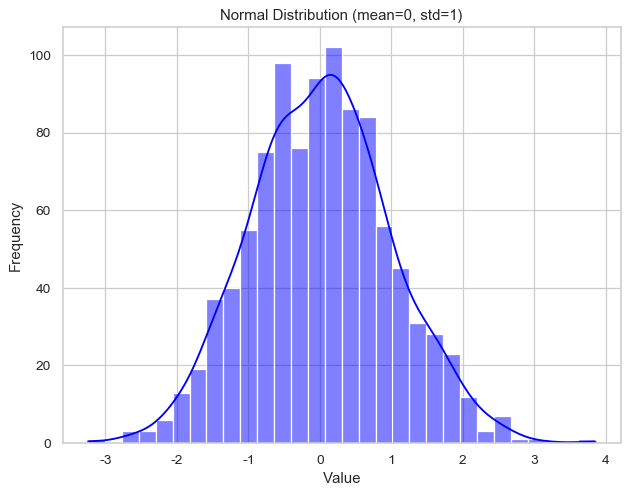

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 生成正态分布数据
mu, sigma = 0, 1  # 均值为0，标准差为1
data = np.random.normal(mu, sigma, 1000)

# 绘制正态分布图形
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.figure(figsize=(8, 6))
sns.histplot(data, kde=True, color="blue", bins=30)
plt.title("Normal Distribution (mean=0, std=1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

上面的代码生成了一个均值为0，标准差为1的正态分布数据，并绘制了它的分布图。图形中，曲线展示了数据的密度分布，呈现出经典的钟形。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

## 公式推导

正态分布的概率密度函数（PDF）由以下公式给出：


$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$


其中：

$\mu$是均值，决定分布的中心位置。

$\sigma$是标准差，决定分布的宽度。

**推导细节**：

1. 正态分布的公式来源于对独立同分布的随机变量的和的极限分布的分析（即中央极限定理）。
2. 在推导过程中，通过极限分析及特定函数的傅里叶变换，最终得出具有指数形式的概率密度函数。
3. 公式中的分母部分确保了函数的标准化，即整个概率密度函数的积分为1。

## Python实现

**生成正态分布数据**：

In [3]:
import numpy as np

# 设置均值和标准差
mu, sigma = 10, 2

# 生成1000个正态分布的数据
data = np.random.normal(mu, sigma, 1000)

# 输出前10个数据
print(data[:10])

[12.79871087 11.84926737 10.11926074  8.70612644 11.39644663 10.78697077
 11.79038644 11.2703436  12.09910543  8.92952958]


**可视化正态分布**：

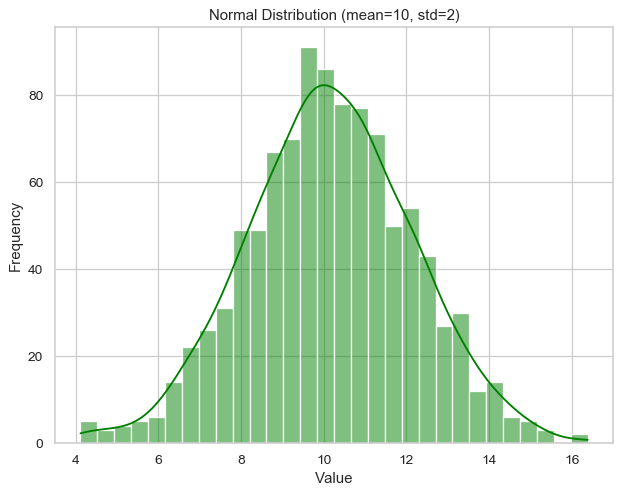

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制数据的分布
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.figure(figsize=(8, 6))
sns.histplot(data, kde=True, color="green", bins=30)
plt.title("Normal Distribution (mean=10, std=2)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_019.png)

**机器学习中的应用**：

在机器学习中，正态分布被广泛应用于数据建模和特征工程。例如，在朴素贝叶斯分类器中，假设特征符合正态分布，可以使用正态分布的概率密度函数来计算后验概率。

In [5]:
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 生成一个简单的二分类数据集
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, random_state=42)

# 分割数据为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 使用高斯朴素贝叶斯模型
model = GaussianNB()
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 输出准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 87.00%


那么，这个代码的话给大家演示了如何使用Python和scikit-learn库应用高斯朴素贝叶斯模型。这个模型假设数据的各个特征符合正态分布，在实际的分类任务中表现良好。

最后和大家总结一句：正态分布是一个非常重要的概率分布，一定要理解其中的核心逻辑和意义。